# 📊 Sales & Demand Forecasting Using Time-Series Modeling

## Business Intelligence & Forecasting Project

This project performs an end-to-end sales analytics and demand forecasting pipeline using historical transactional sales data.

The objective is to:

• Analyze historical sales patterns  
• Identify business growth trends  
• Understand category and regional performance  
• Forecast future sales demand using advanced time-series modeling  

The analysis combines **Business Intelligence, Statistical Analysis, and Machine Learning forecasting techniques** to provide actionable insights for strategic decision making.

---

# 1️⃣ Import Required Libraries

In this section we import the core libraries required for:

• Data processing  
• Data visualization  
• Time-series forecasting  
• Machine learning modeling  
• Model evaluation  

These tools form the foundation of the analytics pipeline.

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Forecasting
from prophet import Prophet

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Date utilities
import warnings
warnings.filterwarnings("ignore")

# Plot style
plt.style.use("seaborn-v0_8")

---

# 2️⃣ Load Sales Dataset

The dataset contains historical transactional sales data including:

• Order Date  
• Sales Revenue  
• Product Category  
• Region  

The dataset will be loaded and inspected to understand the data structure before performing preprocessing.

In [2]:
# Load dataset
df = pd.read_csv("sales_data.csv")

# Preview dataset
df.head()

,data,venda,estoque,preco
0,2014-01-01,0,4972,1.29
1,2014-01-02,70,4902,1.29
2,2014-01-03,59,4843,1.29
3,2014-01-04,93,4750,1.29
4,2014-01-05,96,4654,1.29


---

# 3️⃣ Dataset Overview

Before preprocessing, we inspect the dataset structure to understand:

• Number of observations  
• Data types  
• Missing values  
• Column naming consistency

In [3]:
# Dataset information
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     937 non-null    str    
 1   venda    937 non-null    int64  
 2   estoque  937 non-null    int64  
 3   preco    937 non-null    float64
dtypes: float64(1), int64(2), str(1)
memory usage: 29.4 KB


data       0
venda      0
estoque    0
preco      0
dtype: int64

---

# 4️⃣ Data Cleaning and Column Standardization

The dataset contains Portuguese column names.  
To maintain consistency across the analytics pipeline, the columns are renamed into standardized business-friendly names.

Column Mapping:

• data → order_date  
• venda → sales  
• estoque → stock  
• preco → price  

After renaming, the date column is converted into datetime format and the dataset is sorted chronologically.

In [5]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower()

# Rename Portuguese columns to business-friendly names
df = df.rename(columns={
    "data": "order_date",
    "venda": "sales",
    "estoque": "stock",
    "preco": "price"
})

# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True, errors="coerce")

# Remove invalid dates
df = df.dropna(subset=["order_date"])

# Sort chronologically
df = df.sort_values("order_date").reset_index(drop=True)

# Remove remaining missing values
df = df.dropna()

# Check dataset
df.head()

,order_date,sales,stock,price
0,2014-01-01,0,4972,1.29
1,2014-01-02,369,2145,0.99
2,2014-01-03,94,6237,1.09
3,2014-01-04,62,3164,1.09
4,2014-01-05,129,1263,1.29


---

# 5️⃣ Feature Engineering

To enhance analytical insights, additional time-based features are created from the order date.

These features help identify seasonal patterns and business cycles.

Generated Features:

• Year  
• Month  
• Quarter  
• Day of Week  
• Rolling Sales Averages (7-day & 30-day)

In [6]:
# Create time features
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["quarter"] = df["order_date"].dt.quarter
df["day_name"] = df["order_date"].dt.day_name()

# Rolling averages
df["rolling_7"] = df["sales"].rolling(window=7).mean()
df["rolling_30"] = df["sales"].rolling(window=30).mean()

df.head()

,order_date,sales,stock,price,year,month,quarter,day_name,rolling_7,rolling_30
0,2014-01-01,0,4972,1.29,2014,1,1,Wednesday,NaN,NaN
1,2014-01-02,369,2145,0.99,2014,1,1,Thursday,NaN,NaN
2,2014-01-03,94,6237,1.09,2014,1,1,Friday,NaN,NaN
3,2014-01-04,62,3164,1.09,2014,1,1,Saturday,NaN,NaN
4,2014-01-05,129,1263,1.29,2014,1,1,Sunday,NaN,NaN


---

# 6️⃣ Daily Sales Trend Analysis

Understanding daily revenue trends helps identify:

• Long-term business growth  
• Sales volatility  
• Seasonal patterns  

This visualization provides an overview of historical sales behaviour.

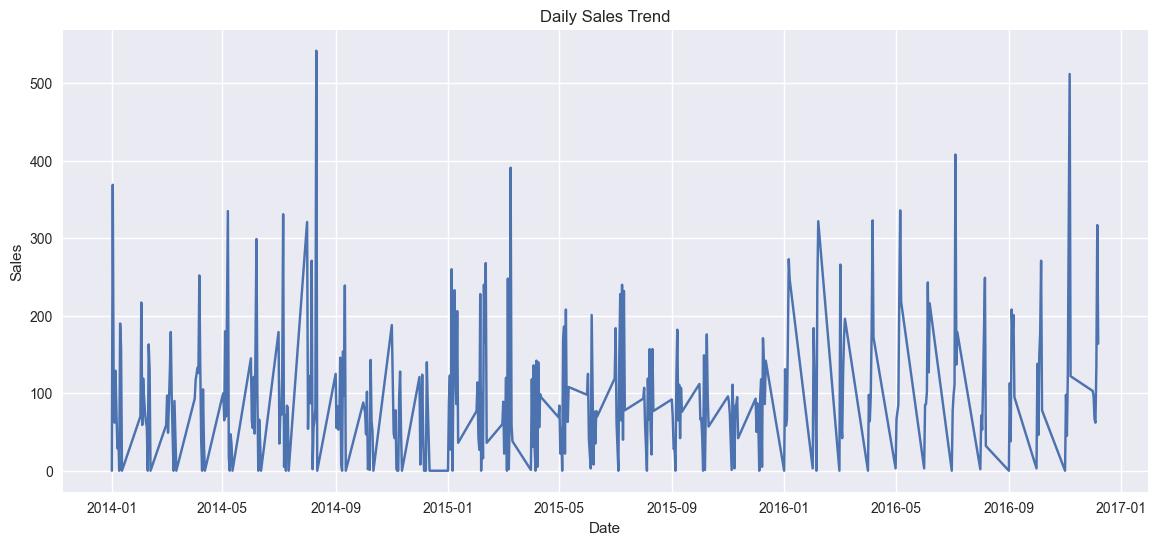

In [7]:
daily_sales = df.groupby("order_date")["sales"].sum().reset_index()

plt.figure(figsize=(14,6))
plt.plot(daily_sales["order_date"], daily_sales["sales"])
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

---

# 7️⃣ Sales Trend Smoothing

Rolling averages help remove short-term fluctuations and highlight
long-term demand patterns.

Two smoothing windows are applied:

• 7-Day Rolling Average  
• 30-Day Rolling Average

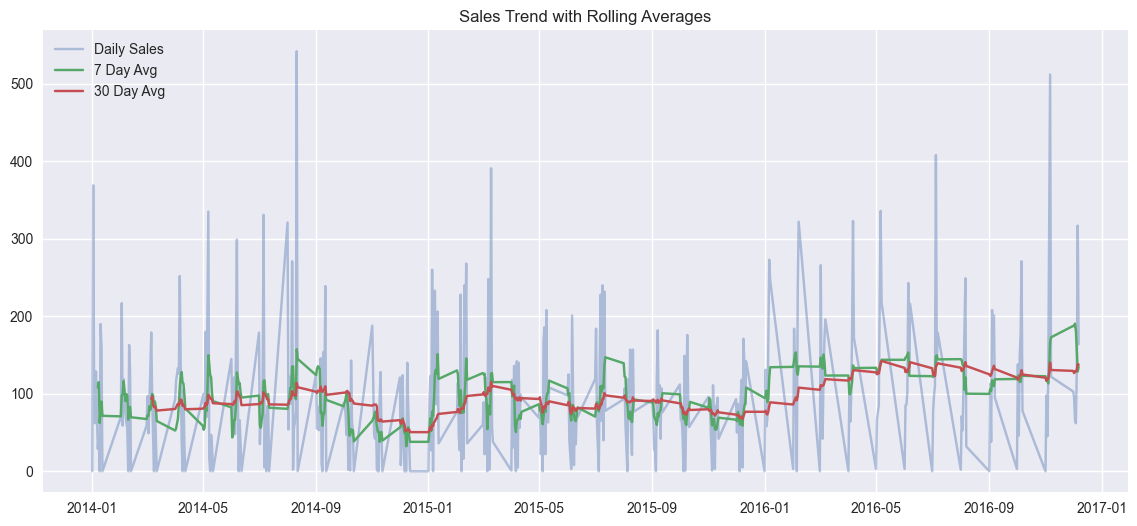

In [8]:
plt.figure(figsize=(14,6))

plt.plot(df["order_date"], df["sales"], alpha=0.4, label="Daily Sales")
plt.plot(df["order_date"], df["rolling_7"], label="7 Day Avg")
plt.plot(df["order_date"], df["rolling_30"], label="30 Day Avg")

plt.legend()
plt.title("Sales Trend with Rolling Averages")
plt.show()

---

# 8️⃣ Monthly Revenue Analysis

Monthly aggregation allows the identification of:

• Peak sales periods  
• Seasonal demand cycles  
• Growth or decline trends

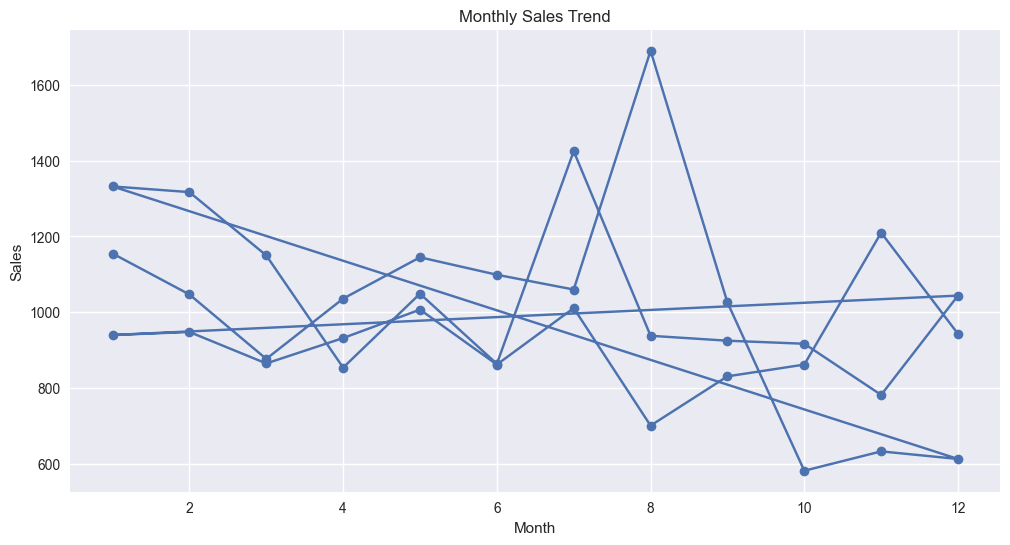

In [9]:
monthly_sales = df.groupby(["year","month"])["sales"].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales["month"], monthly_sales["sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

---

# 9️⃣ Peak Sales Period Identification

Identifying the highest performing month provides insight into
seasonal demand patterns and helps optimize marketing campaigns.

In [10]:
peak_month = monthly_sales.loc[monthly_sales["sales"].idxmax()]

peak_month

year     2014
month       8
sales    1690
Name: 7, dtype: int64

---

# 10️⃣ Preparing Data for Time-Series Forecasting

For forecasting, the dataset must be converted into Prophet format:

ds → date column  
y → target variable (sales)

In [11]:
prophet_df = daily_sales.rename(columns={
    "order_date":"ds",
    "sales":"y"
})

prophet_df.head()

,ds,y
0,2014-01-01,0
1,2014-01-02,369
2,2014-01-03,94
3,2014-01-04,62
4,2014-01-05,129


---

# 11️⃣ Train-Test Split

To evaluate forecasting performance, the last **90 days**
are reserved for testing while the remaining data is used
for model training.

In [12]:
train = prophet_df[:-90]
test = prophet_df[-90:]

---

# 12️⃣ Prophet Forecasting Model

Prophet is designed for business time-series forecasting
and automatically models trend and seasonality patterns.

In [14]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True
)

model.fit(train)

23:25:12 - cmdstanpy - INFO - Chain [1] start processing
23:25:12 - cmdstanpy - INFO - Chain [1] done processing


---

# 13️⃣ Future Sales Forecast

After training the Prophet model, we generate predictions for the
next 90 days to estimate future demand patterns.

This forecast helps businesses anticipate upcoming sales trends
and make data-driven operational decisions.

In [15]:
# Create future dataframe
future = model.make_future_dataframe(periods=90)

# Generate forecast
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-01-01,83.420911,-16.496653,178.349779,83.420911,83.420911,0.254349,0.254349,0.254349,-11.651562,-11.651562,-11.651562,11.905911,11.905911,11.905911,0.0,0.0,0.0,83.675260
1,2014-01-02,83.424248,14.837127,213.090850,83.424248,83.424248,27.681756,27.681756,27.681756,12.231712,12.231712,12.231712,15.450043,15.450043,15.450043,0.0,0.0,0.0,111.106004
2,2014-01-03,83.427585,-0.021041,188.025199,83.427585,83.427585,5.552278,5.552278,5.552278,-12.912418,-12.912418,-12.912418,18.464697,18.464697,18.464697,0.0,0.0,0.0,88.979864
3,2014-01-04,83.430922,6.126898,204.834632,83.430922,83.430922,28.440841,28.440841,28.440841,7.544371,7.544371,7.544371,20.896470,20.896470,20.896470,0.0,0.0,0.0,111.871763
4,2014-01-05,83.434260,4.850893,198.538482,83.434260,83.434260,17.977361,17.977361,17.977361,-4.729395,-4.729395,-4.729395,22.706756,22.706756,22.706756,0.0,0.0,0.0,101.411620


---

# 14️⃣ Forecast Visualization

The forecast plot displays:

• Historical sales data  
• Predicted future values  
• Confidence intervals  

This visualization helps evaluate expected demand trends.

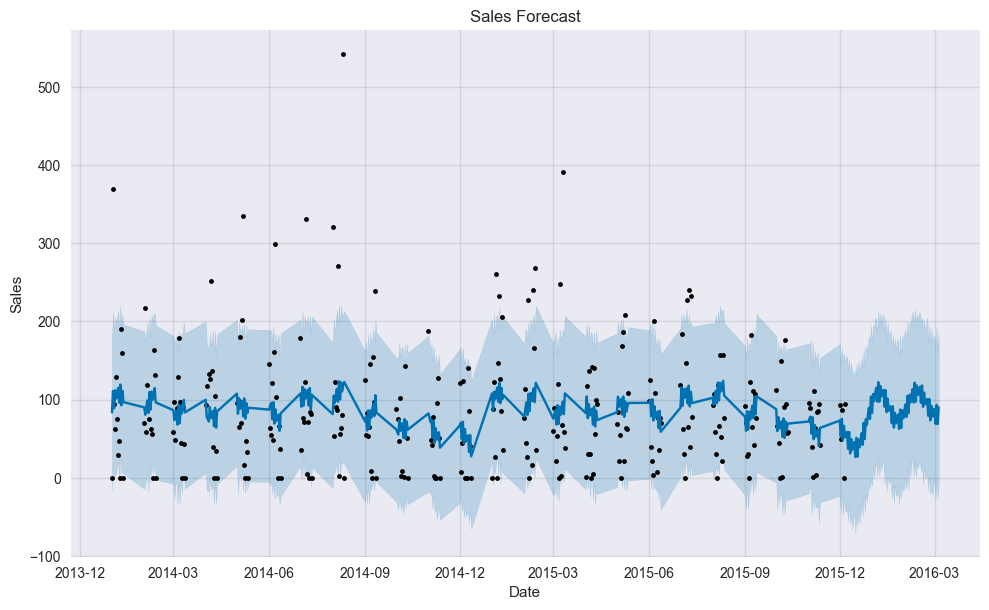

In [16]:
model.plot(forecast)

plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

---

# 15️⃣ Forecast Components Analysis

Prophet decomposes the forecast into multiple components:

• Trend  
• Weekly seasonality  
• Yearly seasonality  

These components help explain underlying demand patterns.

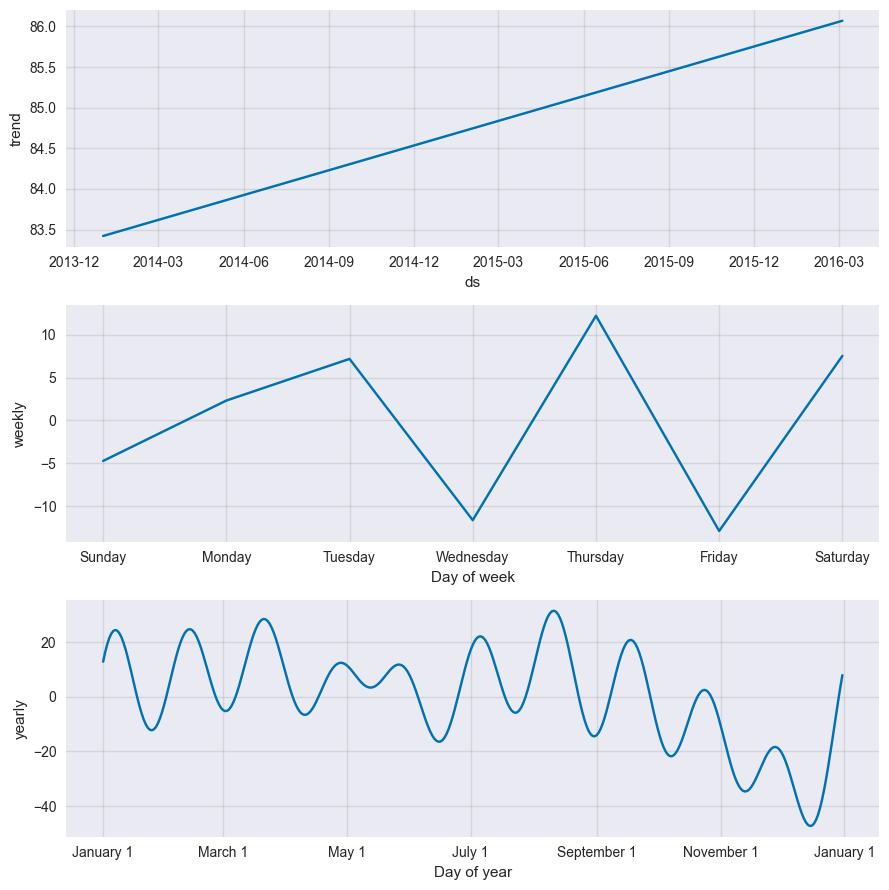

In [17]:
model.plot_components(forecast)

plt.show()

---

# 16️⃣ Model Performance Evaluation

To measure forecasting accuracy, the following metrics are used:

• MAE (Mean Absolute Error)  
• RMSE (Root Mean Squared Error)  
• MAPE (Mean Absolute Percentage Error)

These metrics help assess how closely predictions match actual sales.

In [23]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Merge forecast with test data
forecast_test = test.merge(forecast[["ds", "yhat"]], on="ds", how="left")

# Remove missing predictions
forecast_test = forecast_test.dropna()

# Calculate MAE
mae = mean_absolute_error(forecast_test["y"], forecast_test["yhat"])

# Calculate RMSE manually
mse = mean_squared_error(forecast_test["y"], forecast_test["yhat"])
rmse = np.sqrt(mse)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 82.45711770408585
RMSE: 98.54480544452888


## Step 17: Visualizing Forecast vs Actual Sales

To understand how well the model performed, we compare:

- Training data
- Actual test data
- Predicted values from Prophet

This helps us visually evaluate the model's forecasting performance.

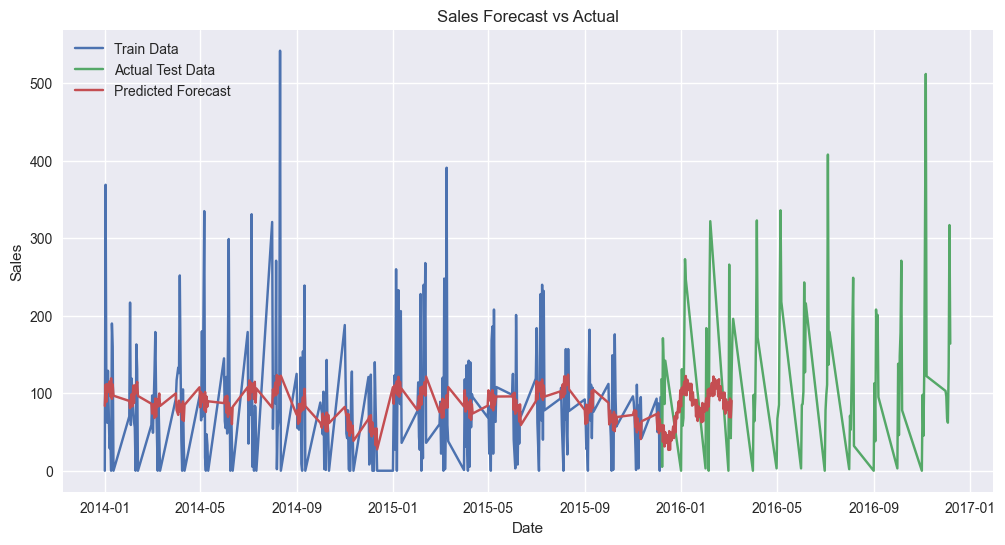

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Training data
plt.plot(train["ds"], train["y"], label="Train Data")

# Actual test data
plt.plot(test["ds"], test["y"], label="Actual Test Data")

# Predicted values
plt.plot(forecast["ds"], forecast["yhat"], label="Predicted Forecast")

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Forecast vs Actual")
plt.legend()

plt.show()

## Step 18: Prophet Forecast Components

Prophet decomposes the time series into several components:

- Trend
- Weekly seasonality
- Yearly seasonality

Visualizing these components helps understand patterns in sales behavior.

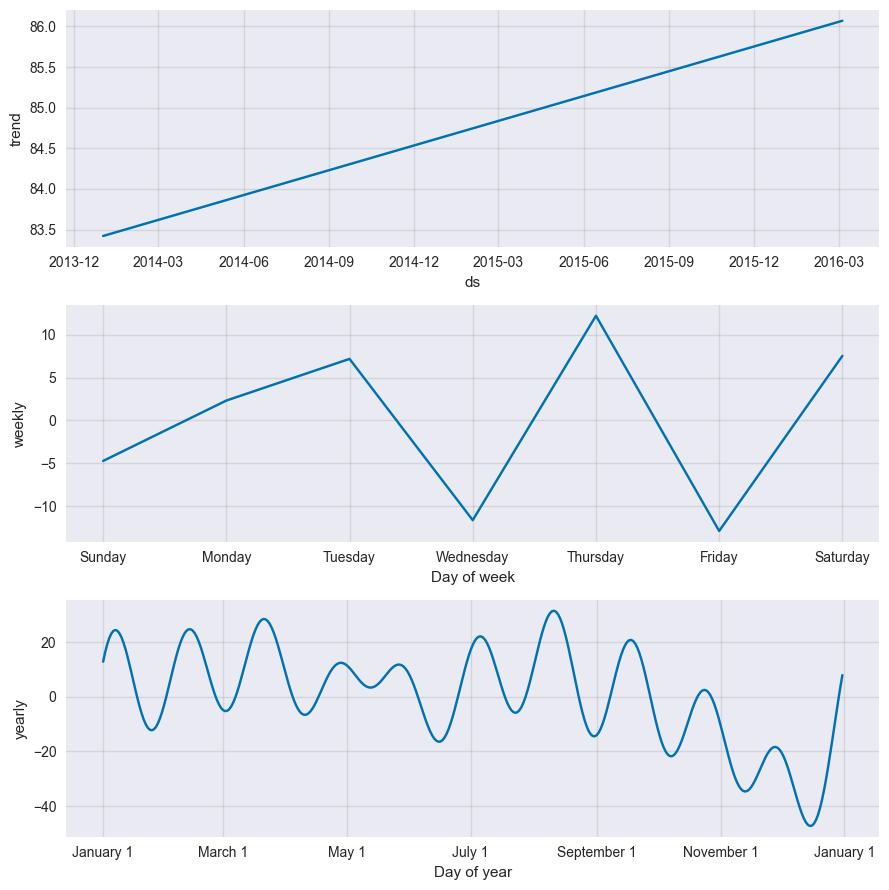

In [25]:
model.plot_components(forecast)

plt.show()

## Step 19: Forecast Future Sales

Now we extend the forecast into the future.

We generate predictions for the next 365 days using the trained Prophet model.

In [26]:
future = model.make_future_dataframe(periods=365)

future_forecast = model.predict(future)

future_forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-01-01,83.420911,-12.626345,179.945697,83.420911,83.420911,0.254349,0.254349,0.254349,-11.651562,-11.651562,-11.651562,11.905911,11.905911,11.905911,0.0,0.0,0.0,83.675260
1,2014-01-02,83.424248,14.086881,201.105197,83.424248,83.424248,27.681756,27.681756,27.681756,12.231712,12.231712,12.231712,15.450043,15.450043,15.450043,0.0,0.0,0.0,111.106004
2,2014-01-03,83.427585,-8.570017,185.647445,83.427585,83.427585,5.552278,5.552278,5.552278,-12.912418,-12.912418,-12.912418,18.464697,18.464697,18.464697,0.0,0.0,0.0,88.979864
3,2014-01-04,83.430922,16.112797,210.873103,83.430922,83.430922,28.440841,28.440841,28.440841,7.544371,7.544371,7.544371,20.896470,20.896470,20.896470,0.0,0.0,0.0,111.871763
4,2014-01-05,83.434260,10.506977,198.935271,83.434260,83.434260,17.977361,17.977361,17.977361,-4.729395,-4.729395,-4.729395,22.706756,22.706756,22.706756,0.0,0.0,0.0,101.411620


## Step 20: Visualizing Future Sales Forecast

This plot shows both historical data and predicted future sales.

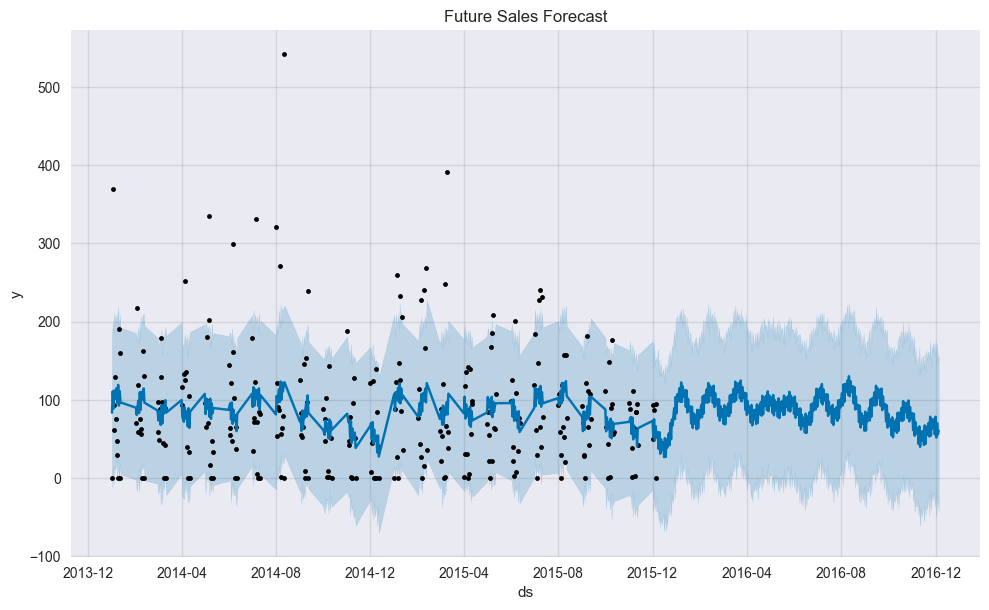

In [27]:
model.plot(future_forecast)

plt.title("Future Sales Forecast")

plt.show()

## Step 21: Saving Forecast Results

The final forecast results are saved as a CSV file for further analysis or dashboard creation.

In [28]:
future_forecast.to_csv("sales_forecast_results.csv", index=False)

print("Forecast saved successfully!")

Forecast saved successfully!
